### **1. Exhaustive Feature Selection**

In [43]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score

import pandas as pd

In [44]:
!pip install --upgrade scikit-learn mlxtend

In [45]:
import seaborn as sns
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [46]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

lr = LogisticRegression()

sel = EFS(lr, max_features = 4, scoring ='accuracy',cv = 5)

In [47]:
model = sel.fit(df.iloc[:,:4],df['species'])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  loss = "log"
Features: 15/15

In [48]:
model.best_score_

np.float64(0.9733333333333334)

In [49]:
model.best_feature_names_

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [50]:
model.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([0.66666667, 0.73333333, 0.76666667, 0.76666667, 0.83333333]),
  'avg_score': np.float64(0.7533333333333333),
  'feature_names': ('sepal_length',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([0.53333333, 0.56666667, 0.53333333, 0.56666667, 0.63333333]),
  'avg_score': np.float64(0.5666666666666667),
  'feature_names': ('sepal_width',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([0.93333333, 1.        , 0.9       , 0.93333333, 1.        ]),
  'avg_score': np.float64(0.9533333333333334),
  'feature_names': ('petal_length',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([1.        , 0.96666667, 0.9       , 0.93333333, 1.        ]),
  'avg_score': np.float64(0.96),
  'feature_names': ('petal_width',)},
 4: {'feature_idx': (0, 1),
  'cv_scores': array([0.73333333, 0.83333333, 0.76666667, 0.86666667, 0.86666667]),
  'avg_score': np.float64(0.8133333333333332),
  'feature_names': ('sepal_length', 'sepal_width')},
 5: {'feature_idx': 

In [51]:
metric_df = pd.DataFrame.from_dict(model.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.6666666666666666, 0.7333333333333333, 0.766...",0.753333,"(sepal_length,)",0.069612,0.05416,0.02708
1,"(1,)","[0.5333333333333333, 0.5666666666666667, 0.533...",0.566667,"(sepal_width,)",0.046932,0.036515,0.018257
2,"(2,)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(petal_length,)",0.051412,0.04,0.02
3,"(3,)","[1.0, 0.9666666666666667, 0.9, 0.9333333333333...",0.96,"(petal_width,)",0.049963,0.038873,0.019437
4,"(0, 1)","[0.7333333333333333, 0.8333333333333334, 0.766...",0.813333,"(sepal_length, sepal_width)",0.069612,0.05416,0.02708
5,"(0, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_length, petal_length)",0.051412,0.04,0.02
6,"(0, 3)","[0.9333333333333333, 0.9666666666666667, 0.933...",0.953333,"(sepal_length, petal_width)",0.034274,0.026667,0.013333
7,"(1, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_width, petal_length)",0.051412,0.04,0.02
8,"(1, 3)","[0.9333333333333333, 0.9666666666666667, 0.9, ...",0.94,"(sepal_width, petal_width)",0.032061,0.024944,0.012472
9,"(2, 3)","[0.9666666666666667, 0.9666666666666667, 0.933...",0.96,"(petal_length, petal_width)",0.032061,0.024944,0.012472


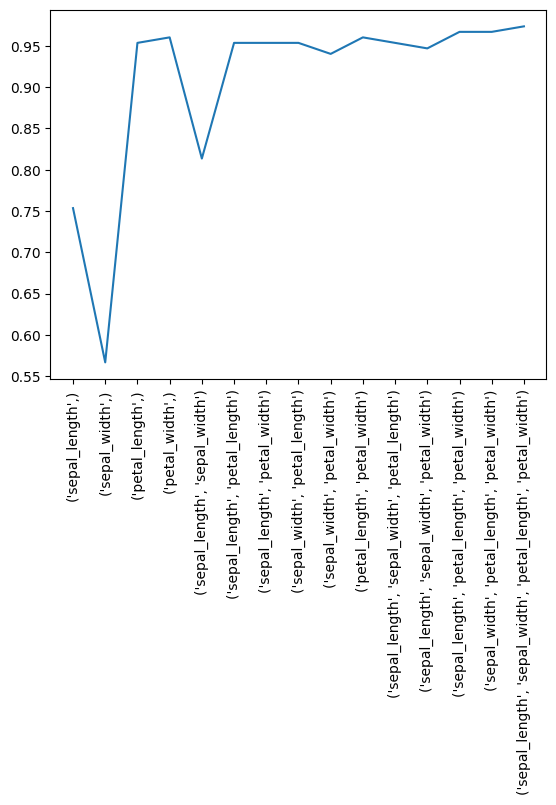

In [52]:
import matplotlib.pyplot as plt

plt.plot([str(k) for k in metric_df['feature_names']], metric_df['avg_score'])
plt.xticks(rotation = 90)
plt.show()

### **Regression Example**

In [53]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(df.iloc[:,:13],df['medv'],test_size = 0.2)

In [69]:
print(X_train.shape,X_test.shape)

(404, 13) (102, 13)


In [70]:
X_train.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
399,9.91655,0.0,18.10,0,0.693,5.852,77.8,1.5004,24,666,20.2,338.16,29.97
465,3.16360,0.0,18.10,0,0.655,5.759,48.2,3.0665,24,666,20.2,334.40,14.13
432,6.44405,0.0,18.10,0,0.584,6.425,74.8,2.2004,24,666,20.2,97.95,12.03
18,0.80271,0.0,8.14,0,0.538,5.456,36.6,3.7965,4,307,21.0,288.99,11.69
360,4.54192,0.0,18.10,0,0.770,6.398,88.0,2.5182,24,666,20.2,374.56,7.79


In [71]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [72]:
# baseline model

import numpy as np
from sklearn.metrics import r2_score
model = LinearRegression()


In [73]:
print("training",np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training 0.7153576995590993
testing 0.6478573313653289


In [75]:
lr = LinearRegression()

In [78]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

exh = EFS(lr, max_features=13, scoring='r2', cv=10, print_progress=True)

sel = exh.fit(X_train, y_train)

Features: 8191/8191

In [65]:
sel.best_score_

np.float64(0.9733333333333334)

In [66]:
sel.best_feature_names_

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [79]:
metric_df = pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.06018367606730124, 0.21381034390445852, 0.1...",0.115334,"(0,)",0.108899,0.146623,0.048874
1,"(1,)","[0.060522099929546824, 0.17581084833135818, 0....",0.117758,"(1,)",0.089269,0.120193,0.040064
2,"(2,)","[0.08428135445695617, 0.36664737133201475, 0.1...",0.23512,"(2,)",0.111209,0.149734,0.049911
3,"(3,)","[0.027036144170834997, 0.017280896371284493, 0...",-0.004748,"(3,)",0.027236,0.036671,0.012224
4,"(4,)","[0.035393980395268865, 0.32423605942149136, 0....",0.177184,"(4,)",0.091491,0.123185,0.041062
...,...,...,...,...,...,...,...
8186,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.6108221109728948, 0.7721609379860932, 0.726...",0.695883,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.085067,0.114535,0.038178
8187,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.6217337231355684, 0.7711252784731025, 0.739...",0.695573,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.085375,0.114951,0.038317
8188,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.6057310379599896, 0.7949827033909533, 0.735...",0.686541,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.093305,0.125627,0.041876
8189,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.6161251533805996, 0.7745926188593906, 0.713...",0.689031,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.082711,0.111363,0.037121


In [80]:
def adjust_r2(r2, num_examples, num_features):
    coef = (num_examples - 1) / (num_examples - num_features - 1)
    return 1 - (1 - r2) * coef

In [81]:
metric_df['observations'] = 404
metric_df['features'] = metric_df['feature_names'].apply(lambda x: len(x))
metric_df['adj_r2'] = adjust_r2(metric_df['avg_score'], metric_df['observations'], metric_df['features'])

In [82]:
metric_df.sort_values('adj_r2',ascending = False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,features,adj_r2
7975,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.611084225497079, 0.7858459777637674, 0.7268...",0.698793,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.085843,0.11558,0.038527,404,10,0.691129
8141,"(0, 1, 2, 4, 5, 7, 8, 9, 10, 11, 12)","[0.6110415076203725, 0.7857512509291116, 0.725...",0.697969,"(0, 1, 2, 4, 5, 7, 8, 9, 10, 11, 12)",0.085896,0.115651,0.03855,404,11,0.689493
8150,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.6222945931518165, 0.7836797102431347, 0.738...",0.697722,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.086092,0.115916,0.038639,404,11,0.68924
8153,"(0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.6108680230167589, 0.7722730581032081, 0.727...",0.696704,"(0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.084995,0.114438,0.038146,404,11,0.688194
8183,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.6223907785983372, 0.7834911997684135, 0.738...",0.696744,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.086923,0.117035,0.039012,404,12,0.687436
...,...,...,...,...,...,...,...,...,...,...
30,"(1, 7)","[0.0498124113996139, 0.1628865627959709, 0.000...",0.113158,"(1, 7)",0.090205,0.121453,0.040484,404,2,0.108735
11,"(11,)","[0.0959523239354213, 0.11700499151959332, 0.06...",0.110287,"(11,)",0.032895,0.04429,0.014763,404,1,0.108074
49,"(3, 7)","[0.027916566591410952, 0.18849442753880163, 0....",0.060166,"(3, 7)",0.056114,0.075553,0.025184,404,2,0.055479
7,"(7,)","[-0.05443988270127198, 0.15436511494982663, -0...",0.044696,"(7,)",0.05995,0.080717,0.026906,404,1,0.04232


In [83]:
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

In [84]:
model = LinearRegression()

print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.7183040676931591
testing 0.6872539866954128


### **2. Sequential Backward Elimination**

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [86]:
# load the dataset
data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [87]:
# separate the target variable
X = data.drop("medv", axis=1)
y = data['medv']

In [88]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [90]:
print(X_train.shape)

(404, 13)


In [89]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [91]:
model = LinearRegression()

print("training",np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training 0.7025123301096212
testing 0.6514899901155402


In [92]:
lr = LinearRegression()

# perform backward elimination

sfs = SFS(lr,k_features = 'best',forward = True, floating = False, scoring = 'r2',cv = 5)
sfs.fit(X_train,y_train)

SequentialFeatureSelector(estimator=LinearRegression(), k_features=(1, 13),
                          scoring='r2')

In [93]:
sfs.k_feature_idx_

(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)

In [94]:
metric_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T

metric_df ['observations'] = 404

metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x:len(x))

metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

In [95]:
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
1,"(12,)","[0.5472998394577442, 0.49002001493399727, 0.53...",0.538451,"(12,)",0.032755,0.025485,0.012742,404,1,0.537303
2,"(5, 12)","[0.6330856272904802, 0.5779812120755249, 0.586...",0.613259,"(5, 12)",0.034066,0.026505,0.013252,404,2,0.61133
3,"(5, 10, 12)","[0.7215896884753016, 0.6288372046797153, 0.633...",0.661012,"(5, 10, 12)",0.04259,0.033136,0.016568,404,3,0.65847
4,"(5, 10, 11, 12)","[0.7258772165486241, 0.6342604286872173, 0.655...",0.667383,"(5, 10, 11, 12)",0.039611,0.030819,0.01541,404,4,0.664048
5,"(5, 7, 10, 11, 12)","[0.7440756174774326, 0.6473449858158778, 0.614...",0.671496,"(5, 7, 10, 11, 12)",0.055057,0.042836,0.021418,404,5,0.667369
6,"(4, 5, 7, 10, 11, 12)","[0.7554472741494642, 0.6695521143038103, 0.653...",0.68562,"(4, 5, 7, 10, 11, 12)",0.047626,0.037054,0.018527,404,6,0.680869
7,"(1, 4, 5, 7, 10, 11, 12)","[0.754884343390746, 0.6798073590310515, 0.6621...",0.6913,"(1, 4, 5, 7, 10, 11, 12)",0.042762,0.03327,0.016635,404,7,0.685844
8,"(0, 1, 4, 5, 7, 10, 11, 12)","[0.7678201537729974, 0.6827004362205137, 0.671...",0.695442,"(0, 1, 4, 5, 7, 10, 11, 12)",0.048774,0.037948,0.018974,404,8,0.689274
9,"(0, 1, 4, 5, 7, 8, 10, 11, 12)","[0.7746648196407366, 0.6850585456872307, 0.683...",0.703763,"(0, 1, 4, 5, 7, 8, 10, 11, 12)",0.04762,0.03705,0.018525,404,9,0.696996
10,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7769593921905562, 0.6884741223718953, 0.702...",0.710033,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.046075,0.035848,0.017924,404,10,0.702654


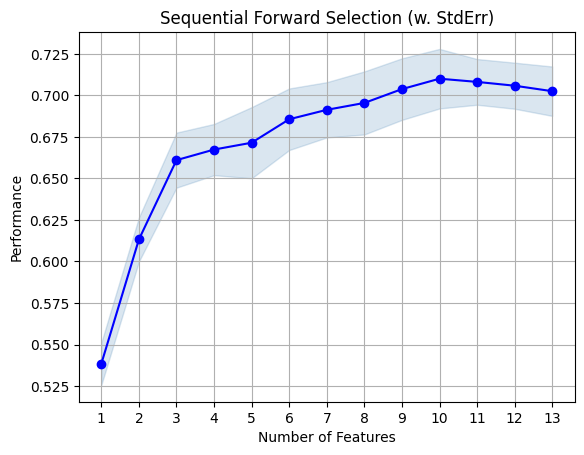

In [96]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(),kind = 'std_err')

plt.title('Sequential Forward Selection (w. StdErr)')
plt.grid()
plt.show()

In [97]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

In [98]:
model = LinearRegression()

print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.7100327839218561
testing 0.7205819296124483


In [99]:
X_train_sel.shape

(404, 10)

### **3. Sequential Forward Selection**

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [101]:
# load the dataset
df2 = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [ ]:
# separate the target variable
X = df2.drop("medv", axis=1)
y = df2['medv']

In [102]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)


(404, 13)


In [103]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [104]:
model2 = LinearRegression()

print("training",np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test, y_test, cv=5, scoring='r2')))

training 0.7025123301096212
testing 0.6514899901155402


In [109]:
lr = LinearRegression()

# perform forward selection
sfs = SFS(lr, k_features='best', forward=False, floating=False, scoring='r2',cv=5)

sfs.fit(X_train, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), forward=False,
                          k_features=(1, 13), scoring='r2')

In [110]:
sfs.k_feature_idx_

(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)

In [111]:
metric_df1 = pd.DataFrame.from_dict(sfs.get_metric_dict()).T

metric_df1['observations'] = 404
metric_df1['num_features'] = metric_df['feature_idx'].apply(lambda x:len(x))
metric_df1['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

metric_df1

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7535027170817177, 0.6920238509138776, 0.682...",0.702512,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.038207,0.029727,0.014863,404,13,0.692596
12,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7532855958710695, 0.6944570477695304, 0.693...",0.70581,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035641,0.02773,0.013865,404,12,0.696781
11,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7547108925568492, 0.6959627893665097, 0.701...",0.708109,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035367,0.027516,0.013758,404,11,0.699918
10,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7769593921905562, 0.6884741223718953, 0.702...",0.710033,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.046075,0.035848,0.017924,404,10,0.702654
9,"(0, 1, 4, 5, 7, 8, 9, 10, 12)","[0.7706104220711025, 0.6854023389684323, 0.690...",0.704324,"(0, 1, 4, 5, 7, 8, 9, 10, 12)",0.046449,0.036139,0.018069,404,9,0.696996
8,"(0, 1, 4, 5, 7, 8, 10, 12)","[0.7681719744800458, 0.6822126526818693, 0.670...",0.697727,"(0, 1, 4, 5, 7, 8, 10, 12)",0.04882,0.037984,0.018992,404,8,0.689274
7,"(0, 1, 4, 5, 7, 10, 12)","[0.7671638009750724, 0.6812300799626649, 0.661...",0.692234,"(0, 1, 4, 5, 7, 10, 12)",0.051644,0.040181,0.02009,404,7,0.685844
6,"(1, 4, 5, 7, 10, 12)","[0.7519120213497091, 0.6756087674652564, 0.646...",0.686004,"(1, 4, 5, 7, 10, 12)",0.046845,0.036447,0.018224,404,6,0.680869
5,"(4, 5, 7, 10, 12)","[0.7525552802357769, 0.6665033988504306, 0.639...",0.681065,"(4, 5, 7, 10, 12)",0.051233,0.039861,0.019931,404,5,0.667369
4,"(5, 7, 10, 12)","[0.7384743962575442, 0.6401188507668829, 0.587...",0.662544,"(5, 7, 10, 12)",0.063384,0.049315,0.024658,404,4,0.664048


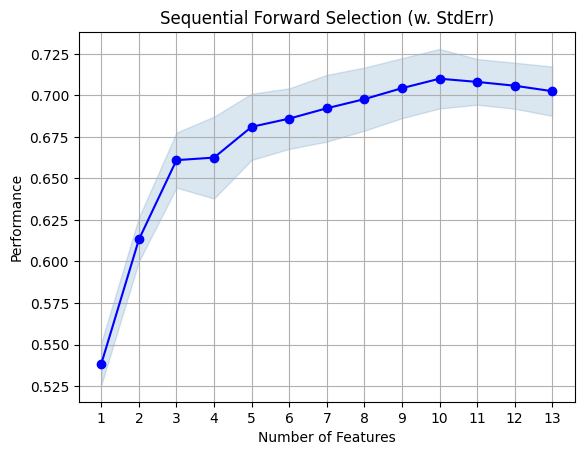

In [112]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_err',)

plt.title('Sequential Forward Selection (w. StdErr)')
plt.grid()
plt.show()

In [113]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

model = LinearRegression()

print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.7100327839218561
testing 0.7205819296124483
